In [34]:
# 모델의 효율성 향상을 위한 네트워크 확장
# fashion mnist dateset 이용
# 1) Conv + Dense,
# 2) Conv + Pooling + Dense,
# 3) 유명모델의 네트워크 사용 모델

# 위 방법들을 사용해 모델 작성 후 성능 비교

import tensorflow as tf

fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

(60000, 28, 28)
(10000, 28, 28)
(60000, 28, 28, 1)
(10000, 28, 28, 1)


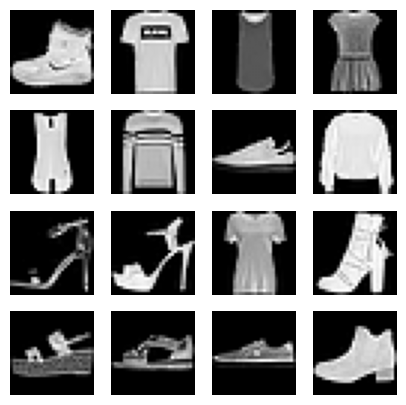

[9 0 0 3 0 2 7 2 5 5 0 9 5 5 7 9]


In [35]:
# 정규화
x_train, x_test = x_train / 255.0, x_test / 255.0

# reshape 이전
print(x_train.shape)   # (60000, 28, 28)
print(x_test.shape)   # (10000, 28, 28)

# reshape 이후
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
print(x_train.shape)  # (60000, 28, 28, 1)
print(x_test.shape)   # (10000, 28, 28, 1)

# 데이터 확인(시각화)
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.show()

print(y_train[:16])

In [36]:
# 1) Conv + Dense 신경망 모델 생성
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu'),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

print(model.summary())

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_37 (Conv2D)              │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 24, 24, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 22, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │     1,982,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,008,234 (7.66 MB)

 Trainable params: 2,008,234 (7.66 MB)

 Non-trainable params: 0 (0.00 B)

None


In [37]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=15, validation_split=0.25, verbose=2)
model.evaluate(x_test, y_test, verbose=0)

print(f"loss : {history.history['loss'][-1]}")
print(f"val_loss : {history.history['val_loss'][-1]}")
print(f"accuracy : {history.history['accuracy'][-1]}")
print(f"val_accuracy : {history.history['val_accuracy'][-1]}")


Epoch 1/15
1407/1407 - 14s - 10ms/step - accuracy: 0.7998 - loss: 0.5820 - val_accuracy: 0.8722 - val_loss: 0.3582
Epoch 2/15
1407/1407 - 7s - 5ms/step - accuracy: 0.8750 - loss: 0.3540 - val_accuracy: 0.8926 - val_loss: 0.2931
Epoch 3/15
1407/1407 - 10s - 7ms/step - accuracy: 0.8984 - loss: 0.2854 - val_accuracy: 0.9023 - val_loss: 0.2675
Epoch 4/15
1407/1407 - 7s - 5ms/step - accuracy: 0.9141 - loss: 0.2433 - val_accuracy: 0.9110 - val_loss: 0.2440
Epoch 5/15
1407/1407 - 6s - 5ms/step - accuracy: 0.9267 - loss: 0.2048 - val_accuracy: 0.9149 - val_loss: 0.2446
Epoch 6/15
1407/1407 - 7s - 5ms/step - accuracy: 0.9380 - loss: 0.1748 - val_accuracy: 0.9177 - val_loss: 0.2431
Epoch 7/15
1407/1407 - 7s - 5ms/step - accuracy: 0.9472 - loss: 0.1500 - val_accuracy: 0.9170 - val_loss: 0.2626
Epoch 8/15
1407/1407 - 7s - 5ms/step - accuracy: 0.9560 - loss: 0.1267 - val_accuracy: 0.9107 - val_loss: 0.2945
Epoch 9/15
1407/1407 - 11s - 8ms/step - accuracy: 0.9602 - loss: 0.1097 - val_accuracy: 0.915

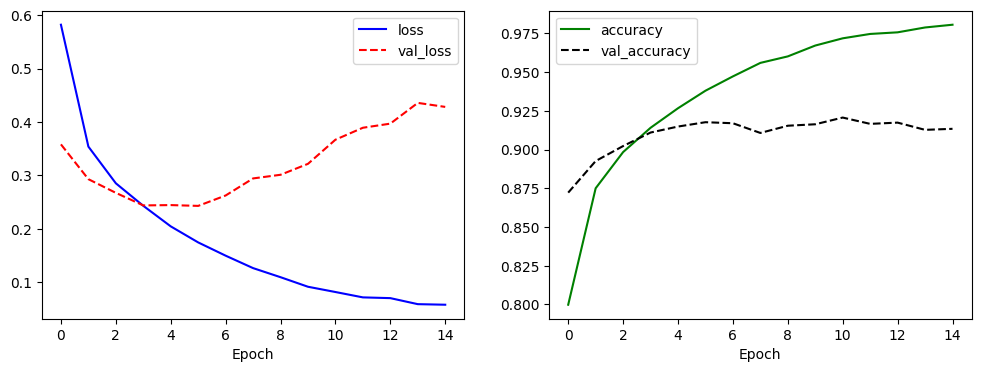

In [38]:
# 성능 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'b-', label='loss')
plt.plot(history.history['val_loss'], 'r--', label='val_loss')
plt.xlabel('Epoch')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'g-', label='accuracy')
plt.plot(history.history['val_accuracy'], 'k--', label='val_accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [39]:
# 2) Conv + Pooling + Dense 모델 정의

model2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='softmax')
])
print(model2.summary())

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 3, 3, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,866 (116.66 KB)

 Trainable params: 29,866 (116.66 KB)

 Non-trainable params: 0 (0.00 B)

None


In [40]:
model2.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model2.fit(x_train, y_train, epochs=15, validation_split=0.25, verbose=2)
model2.evaluate(x_test, y_test, verbose=0)

print(f"loss : {history.history['loss'][-1]}")
print(f"val_loss : {history.history['val_loss'][-1]}")
print(f"accuracy : {history.history['accuracy'][-1]}")
print(f"val_accuracy : {history.history['val_accuracy'][-1]}")


Epoch 1/15
1407/1407 - 14s - 10ms/step - accuracy: 0.6359 - loss: 0.9870 - val_accuracy: 0.7765 - val_loss: 0.6018
Epoch 2/15
1407/1407 - 6s - 4ms/step - accuracy: 0.7642 - loss: 0.6695 - val_accuracy: 0.8112 - val_loss: 0.5152
Epoch 3/15
1407/1407 - 5s - 4ms/step - accuracy: 0.7939 - loss: 0.5905 - val_accuracy: 0.8317 - val_loss: 0.4595
Epoch 4/15
1407/1407 - 6s - 4ms/step - accuracy: 0.8144 - loss: 0.5384 - val_accuracy: 0.8373 - val_loss: 0.4434
Epoch 5/15
1407/1407 - 5s - 4ms/step - accuracy: 0.8267 - loss: 0.5010 - val_accuracy: 0.8506 - val_loss: 0.4007
Epoch 6/15
1407/1407 - 6s - 4ms/step - accuracy: 0.8381 - loss: 0.4687 - val_accuracy: 0.8532 - val_loss: 0.3952
Epoch 7/15
1407/1407 - 5s - 4ms/step - accuracy: 0.8453 - loss: 0.4503 - val_accuracy: 0.8567 - val_loss: 0.3951
Epoch 8/15
1407/1407 - 10s - 7ms/step - accuracy: 0.8520 - loss: 0.4339 - val_accuracy: 0.8655 - val_loss: 0.3661
Epoch 9/15
1407/1407 - 6s - 4ms/step - accuracy: 0.8568 - loss: 0.4151 - val_accuracy: 0.8632

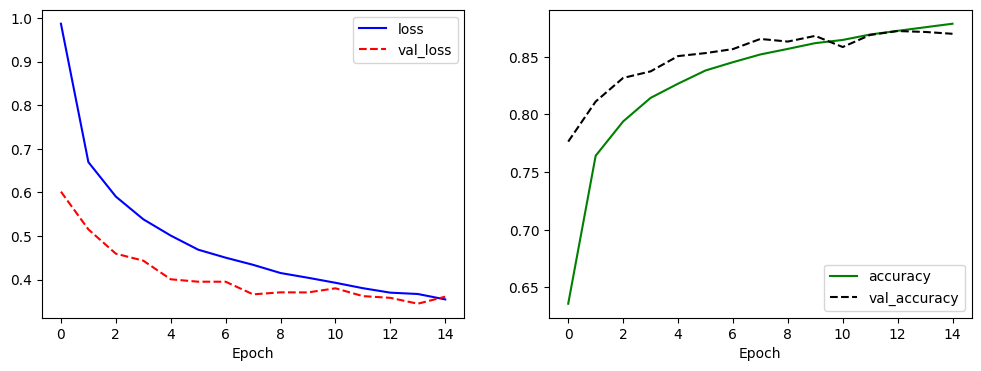

In [41]:
# 성능 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'b-', label='loss')
plt.plot(history.history['val_loss'], 'r--', label='val_loss')
plt.xlabel('Epoch')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'g-', label='accuracy')
plt.plot(history.history['val_accuracy'], 'k--', label='val_accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [42]:
# 3) 유명모델의 네트워크 사용 모델(VGG) 이용
model3 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(input_shape=(28,28,1), kernel_size=(3,3), filters=32, padding='same', activation='relu'),
    tf.keras.layers.Conv2D(kernel_size=(3,3), filters=64, padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2,2)),
    tf.keras.layers.Dropout(rate=0.5),
    tf.keras.layers.Conv2D(kernel_size=(3,3), filters=128, padding='same', activation='relu'),
    tf.keras.layers.Conv2D(kernel_size=(3,3), filters=256, padding='valid', activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2,2)),
    tf.keras.layers.Dropout(rate=0.5),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=512, activation='relu'),
    tf.keras.layers.Dropout(rate=0.5),
    tf.keras.layers.Dense(units=256, activation='relu'),
    tf.keras.layers.Dropout(rate=0.5),
    tf.keras.layers.Dense(units=10, activation='softmax')
])
print(model3.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_43 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,240,842 (19.99 MB)

 Trainable params: 5,240,842 (19.99 MB)

 Non-trainable params: 0 (0.00 B)

None


In [43]:
model3.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model3.fit(x_train, y_train, epochs=15, validation_split=0.25, verbose=2)
model3.evaluate(x_test, y_test, verbose=0)

print(f"loss : {history.history['loss'][-1]}")
print(f"val_loss : {history.history['val_loss'][-1]}")
print(f"accuracy : {history.history['accuracy'][-1]}")
print(f"val_accuracy : {history.history['val_accuracy'][-1]}")

Epoch 1/15
1407/1407 - 27s - 19ms/step - accuracy: 0.7810 - loss: 0.6014 - val_accuracy: 0.8745 - val_loss: 0.3346
Epoch 2/15
1407/1407 - 12s - 8ms/step - accuracy: 0.8673 - loss: 0.3719 - val_accuracy: 0.8925 - val_loss: 0.2848
Epoch 3/15
1407/1407 - 11s - 8ms/step - accuracy: 0.8822 - loss: 0.3301 - val_accuracy: 0.9082 - val_loss: 0.2556
Epoch 4/15
1407/1407 - 20s - 15ms/step - accuracy: 0.8899 - loss: 0.3084 - val_accuracy: 0.9052 - val_loss: 0.2538
Epoch 5/15
1407/1407 - 11s - 8ms/step - accuracy: 0.8958 - loss: 0.2912 - val_accuracy: 0.9077 - val_loss: 0.2455
Epoch 6/15
1407/1407 - 11s - 8ms/step - accuracy: 0.9003 - loss: 0.2832 - val_accuracy: 0.9149 - val_loss: 0.2278
Epoch 7/15
1407/1407 - 11s - 8ms/step - accuracy: 0.9016 - loss: 0.2736 - val_accuracy: 0.9199 - val_loss: 0.2146
Epoch 8/15
1407/1407 - 11s - 8ms/step - accuracy: 0.9048 - loss: 0.2622 - val_accuracy: 0.9225 - val_loss: 0.2153
Epoch 9/15
1407/1407 - 11s - 8ms/step - accuracy: 0.9067 - loss: 0.2579 - val_accuracy

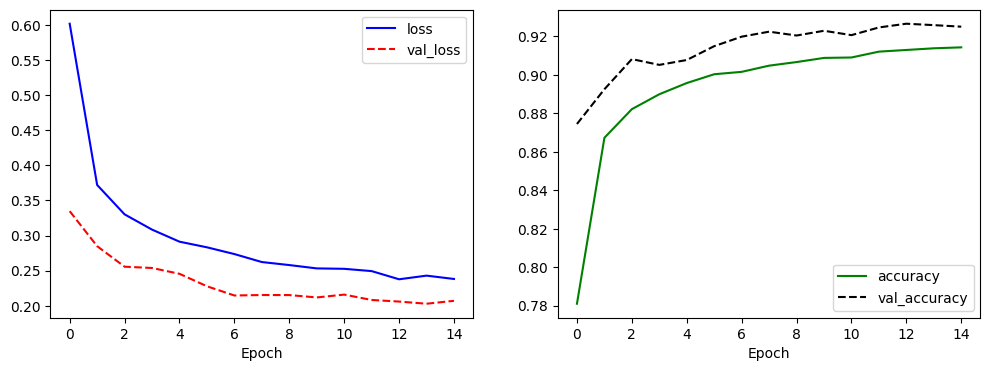

In [44]:
# 성능 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'b-', label='loss')
plt.plot(history.history['val_loss'], 'r--', label='val_loss')
plt.xlabel('Epoch')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'g-', label='accuracy')
plt.plot(history.history['val_accuracy'], 'k--', label='val_accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()